# G-DAE Stellar Decontamination and Uncertainty Analysis

This notebook evaluates the General Denoising AutoEncoder (G-DAE) used to reduce stellar-contamination and observational-noise signatures in Earth-like transmission spectra for a TRAPPIST-1e analog. The workflow compares contaminated/noisy inputs, clean reference spectra, and G-DAE reconstructions under heterogeneous stellar surfaces with spots and faculae.

**Key Objectives & Workflow:**
1. **Contamination Injection**: apply synthetic stellar heterogeneity to planetary transmission spectra.
2. **PandExo Noise Injection**: simulate JWST/NIRSpec Prism instrumental noise for performance tests.
3. **G-DAE Reconstruction Assessment**: quantify the recovery of planetary signals with residuals and reduced $\chi^2$ metrics.
4. **Uncertainty Estimation**: combine an aleatoric term tied to the instrumental-noise profile with an epistemic term estimated from MC Dropout, then propagate the total uncertainty into the reconstruction diagnostics.


# Initialize Data and Wavenumber Grid


In [1]:
import gc
import os
import re
import sys
import warnings
from tqdm import tqdm

# Third-party imports
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import multirex as mrex
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
# Note: Ensure pandexo is installed 
import pandexo.engine.justdoit as jdi


# Typing imports
from typing import Any, List, Optional, Union, Tuple, Dict

Loading MultiREx version 0.3.1


In [2]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral", "DejaVu Serif", "Times New Roman", "CMU Serif", "Liberation Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["axes.titlesize"]    = 14
mpl.rcParams["axes.titleweight"]  = "normal"
mpl.rcParams["axes.titlepad"]     = 10
mpl.rcParams["figure.titlesize"]  = 16
mpl.rcParams["figure.titleweight"] = "normal"

In [3]:
def configure_warnings() -> None:
    """
    Configure global warning filters.

    Suppresses DeprecationWarning to ensure cleaner notebook output during
    execution.
    """
    warnings.filterwarnings("ignore", category=DeprecationWarning)

# Apply configuration
configure_warnings()

In [4]:
# --- Data Loading & Processing ---

# Assumption: 'waves.txt' is present in the current working directory.
waves: np.ndarray = np.loadtxt("waves.txt")

N_POINTS: int = len(waves)

# Calculate Wavenumber Grid
# Physical conversion: 10,000 / wavelength (microns) = wavenumber (cm^-1).
# The grid is sorted to ensure monotonic increase.
wn_grid: np.ndarray = np.sort(10000.0 / waves)


def attach_spectrum_blocks(df: pd.DataFrame, n_data_columns: int) -> pd.DataFrame:
    """Attach local `.data` and `.params` views used by this notebook."""
    object.__setattr__(df, "data", df.iloc[:, -n_data_columns:])
    object.__setattr__(df, "params", df.iloc[:, :-n_data_columns])
    return df


# Apply Stellar Contamination and Preprocess Data


In [5]:
# --- Configuration & Constants ---

# List of contamination source files
CONTAMINATION_FILES: List[str] = [
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.70.txt",
]


In [6]:
def apply_contaminations_from_files(
    contamination_files: List[str],
    df: pd.DataFrame,
    N_POINTS: int
) -> pd.DataFrame:
    """
    Applies multiple contamination models to the data from a list of files.

    Returns a concatenated DataFrame containing:
    1. The original non-contaminated case (f_spot=0, f_fac=0).
    2. All contaminated variations found in the file list.

    Args:
        contamination_files: Paths to .txt files containing contamination data.
        df: Original DataFrame.
        N_POINTS: Number of spectral columns (at the end) to modify.

    Returns:
        DataFrame with combined scenarios and new metadata columns.
    """
    df_list: List[pd.DataFrame] = []

    # --- 1. Non-contaminated case ---
    df_no_contam = df.copy()
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0
    
    # Reorder: metadata first, then data
    cols = ["f_spot", "f_fac"] + [c for c in df_no_contam.columns if c not in ["f_spot", "f_fac"]]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    # --- 2. Process Files ---
    # Regex to extract parameters: e.g., fspot0.01_ffac0.08.txt
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"Filename '{filename}' does not match pattern '{pattern}'.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        try:
            # Read contamination: expect at least 2 columns or flattened array
            contam_data = np.loadtxt(file_path, ndmin=2)
            
            if contam_data.shape[1] >= 2:
                contam_values = contam_data[:, 1]
            else:
                contam_values = contam_data.flatten()

            # Traceability: Validate shape matches N_POINTS
            if len(contam_values) != N_POINTS:
                raise ValueError(
                    f"Contamination count in '{filename}' ({len(contam_values)}) "
                    f"!= N_POINTS ({N_POINTS})."
                )
        except Exception as e:
            raise ValueError(f"Error reading {file_path}: {e}")

        # Invert order if necessary (assuming data is stored high-to-low or similar)
        contam_values = contam_values[::-1]

        # Apply contamination logic
        df_contam = df.copy()
        data_cols = df_contam.columns[-N_POINTS:]
        df_contam[data_cols] = df_contam[data_cols].multiply(contam_values, axis=1)

        # Metadata
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        
        # Reorder
        cols = ["f_spot", "f_fac"] + [c for c in df_contam.columns if c not in ["f_spot", "f_fac"]]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    # --- 3. Final Assembly ---
    df_final = pd.concat(df_list, ignore_index=True)
    
    return attach_spectrum_blocks(df_final, N_POINTS)


def filter_rows(df: pd.DataFrame, N_POINTS: int, threshold: float = -8.0) -> pd.DataFrame:
    """
    Filters rows where specific atmospheric chemicals are above a threshold.

    Args:
        df: Input DataFrame.
        N_POINTS: Number of spectral points (used for attribute reconstruction).
        threshold: Cutoff value (default: -8.0).

    Returns:
        Filtered DataFrame with updated .data and .params attributes.
    """
    filter_cols = ["atm CH4", "atm O3", "atm H2O"]
    present_cols = [col for col in filter_cols if col in df.columns]

    for chem in present_cols:
        df = df[df[chem] >= threshold]

    return attach_spectrum_blocks(df, N_POINTS)


def mult_df(df: pd.DataFrame, N_POINTS: int, n_mult: int) -> pd.DataFrame:
    """
    Duplicates the DataFrame (n_mult + 1) times as a 'clean' control group.
    
    Sets 'f_spot' and 'f_fac' to 0.0 for all copies.
    """
    df_list = []
    
    # Create the template 'clean' frame
    df_clean_template = df.copy()
    df_clean_template["f_spot"] = 0.0
    df_clean_template["f_fac"] = 0.0
    
    cols = ["f_spot", "f_fac"] + [c for c in df_clean_template.columns if c not in ["f_spot", "f_fac"]]
    df_clean_template = df_clean_template[cols]

    # Duplicate
    for _ in range(n_mult + 1):
        df_list.append(df_clean_template.copy())

    df_final = pd.concat(df_list, ignore_index=True)
    return attach_spectrum_blocks(df_final, N_POINTS)


REF_FLAT = None
LOG_RATIO_EPS = 1e-12


def infer_ref_flat_from_airless(
    airless_df: pd.DataFrame,
    N_POINTS: int,
    atol: float = 1e-12,
    rtol: float = 1e-8,
) -> float:
    """Infer a scalar flat reference depth from the clean airless spectrum."""
    mask = np.ones(len(airless_df), dtype=bool)

    if "f_spot" in airless_df.columns:
        mask &= np.isclose(airless_df["f_spot"].to_numpy(dtype=float), 0.0)
    if "f_fac" in airless_df.columns:
        mask &= np.isclose(airless_df["f_fac"].to_numpy(dtype=float), 0.0)

    airless_subset = airless_df.loc[mask]
    if airless_subset.empty:
        raise ValueError("Could not find a contamination-free airless spectrum.")

    airless_values = airless_subset.iloc[0, -N_POINTS:].to_numpy(dtype=np.float32)
    ref_flat = float(np.median(airless_values))

    if not np.allclose(airless_values, ref_flat, atol=atol, rtol=rtol):
        raise ValueError("Airless spectrum is not flat enough to define a scalar ref_flat.")
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"Invalid ref_flat inferred from airless spectrum: {ref_flat}")

    return ref_flat


def _wrap_like(original, values):
    if isinstance(original, pd.DataFrame):
        return pd.DataFrame(values, index=original.index, columns=original.columns)
    if isinstance(original, pd.Series):
        return pd.Series(values, index=original.index, name=original.name)
    return values


def to_log_ratio(values, ref_flat, eps=LOG_RATIO_EPS):
    """Transform physical transit depths to log(depth / ref_flat)."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values, dtype=np.float32)
    arr = np.clip(arr, eps, None)
    transformed = np.log(arr / ref_flat).astype(np.float32)
    return _wrap_like(values, transformed)


def from_log_ratio(values_log, ref_flat):
    """Map log(depth / ref_flat) back to physical transit depths."""
    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    arr = np.asarray(values_log, dtype=np.float32)
    restored = (np.exp(arr) * ref_flat).astype(np.float32)
    return _wrap_like(values_log, restored)


In [7]:
# --- Dataset 1: Apply Contaminations ---
# Loading CSVs and applying the contamination models defined in CONTAMINATION_FILES.

datasets_to_process = [
    ("spec_data/airless_data.csv", "airless_data"),
    ("spec_data/CH4_O3_H2O_data.csv", "CH4_O3_H2O_data"),
]

# Dictionary to store results
processed_data = {}

for filepath, name in datasets_to_process:
    try:
        # Load
        df_temp = pd.read_csv(filepath)
        
        # Filter (if applicable)
        # Note: Logic applied to all, but filter_rows checks for column existence internally
        df_temp = filter_rows(df_temp, N_POINTS)
        
        # Apply Contamination
        df_result = apply_contaminations_from_files(CONTAMINATION_FILES, df_temp, N_POINTS)
        
        # Store in dictionary and global variable (for backward compatibility)
        processed_data[name] = df_result
        globals()[name] = df_result # Exposes processed datasets globally
        
        print(f"Successfully processed {name}")
        
    except Exception as e:
        print(f"Error processing {name}: {e}")

C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

Successfully processed airless_data


C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_40616\57093310.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

Successfully processed CH4_O3_H2O_data


In [8]:
# --- Dataset 2: Generate Clean Control Groups ---
# Generating non-contaminated duplicates using mult_df.

clean_datasets = [
    ("spec_data/airless_data.csv", "airless_data_clean"),
    ("spec_data/CH4_O3_H2O_data.csv", "CH4_O3_H2O_data_clean"),
]

MULTIPLIER = 9

for filepath, name in clean_datasets:
    try:
        # Load
        df_temp = pd.read_csv(filepath)
        
        # Filter
        df_temp = filter_rows(df_temp, N_POINTS)
        
        # Generate Clean Copies
        df_result = mult_df(df_temp, N_POINTS, MULTIPLIER)
        
        # Store globally
        globals()[name] = df_result
        
        print(f"Successfully generated {name}")

    except Exception as e:
        print(f"Error generating {name}: {e}")


Successfully generated airless_data_clean
Successfully generated CH4_O3_H2O_data_clean


# Inject Noise and Augment Data


In [9]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: Union[float, np.ndarray, List[float]],
    seed: Optional[int] = None,
) -> pd.DataFrame:
    """Repeat spectra and add Gaussian noise with scalar, wavelength, or row noise."""
    if n_repeat <= 0:
        raise ValueError("n_repeat must be positive.")

    if seed is not None:
        np.random.seed(seed)

    df_params = df.params.reset_index(drop=True)
    df_spectra = df.data.reset_index(drop=True)
    n_rows, n_cols = df_spectra.shape

    spectra_values = np.repeat(df_spectra.values, n_repeat, axis=0)
    params_values = np.repeat(df_params.values, n_repeat, axis=0)

    if np.isscalar(noise_std):
        if noise_std < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_scale = float(noise_std)
        noise_column = noise_scale
    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if np.any(noise_array < 0):
            raise ValueError("noise_std values must be non-negative.")

        if noise_array.shape == (n_cols,):
            noise_scale = noise_array[None, :]
            noise_column = np.full(n_rows * n_repeat, np.nan)
        elif noise_array.shape == (n_rows,):
            noise_scale = np.repeat(noise_array, n_repeat)[:, None]
            noise_column = np.repeat(noise_array, n_repeat)
        else:
            raise ValueError(
                "noise_std must be scalar, length n_wavelengths, or length n_spectra."
            )

    spectra_noisy = spectra_values + np.random.normal(
        loc=0.0,
        scale=noise_scale,
        size=spectra_values.shape,
    )

    df_spectra_rep = pd.DataFrame(spectra_noisy, columns=df_spectra.columns)
    df_params_rep = pd.DataFrame(params_values, columns=df_params.columns)
    df_params_rep.insert(0, "noise_std", noise_column)
    df_params_rep.insert(1, "n_repeat", n_repeat)

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), df_spectra_rep.reset_index(drop=True)],
        axis=1,
    )
    return attach_spectrum_blocks(df_final, n_cols)


## Model Loading & Statistical Metrics

In [10]:
# Load the pre-trained Autoencoder
try:
    autoencoder = keras.models.load_model("Models/G-DAE.keras")
    print(f"Model loaded successfully. Parameter count: {autoencoder.count_params():,}")
except (OSError, IOError) as e:
    print(f"Warning: Model file not found ({e}). Statistical functions below remain usable.")
    autoencoder = None

def chi2(
    x: np.ndarray, 
    x_recon: np.ndarray, 
    sigma: np.ndarray
) -> np.ndarray:
    """
    Calculates the Chi-Squared (χ²) statistic for each sample.

    Formula: Σ ((x - x_recon) / sigma)^2

    Args:
        x: Original spectra, shape (n_samples, N).
        x_recon: Reconstructed spectra, shape (n_samples, N).
        sigma: Uncertainties per spectral point, shape (N,).

    Returns:
        np.ndarray: Array of χ² values, shape (n_samples,).
    """
    # Broadcasting sigma across samples
    return np.sum(((x - x_recon) / sigma) ** 2, axis=1)


def chi2_r(
    x: np.ndarray, 
    x_recon: np.ndarray, 
    sigma: np.ndarray, 
    p: int
) -> np.ndarray:
    """
    Calculates the Reduced Chi-Squared (χ²_ν) statistic.

    Formula: χ² / (N - p)
    Where N is the number of data points (spectral bins) and p is the number 
    of free parameters (degrees of freedom consumed).

    Args:
        x, x_recon, sigma: See calculate_chi2.
        p: Number of parameters (degrees of freedom used).

    Returns:
        np.ndarray: Array of χ²_ν values.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    n_points = x.shape[1]
    
    # Degrees of freedom
    dof = n_points - p
    if dof <= 0:
        warnings.warn(f"Degrees of freedom <= 0 (N={n_points}, p={p}). Returning inf.")
        return np.full_like(chi2_vals, np.inf)
        
    return chi2_vals / dof

Model loaded successfully. Parameter count: 2,024,673


In [11]:
def get_pandexo_noise_from_file(
    file_path: str, 
    n_transits: int, 
    plot: bool = False
) -> np.ndarray:
    """
    Simulates JWST NIRSpec Prism observations to generate a noise profile.

    Reads a spectrum file, configures a specific planetary system scenario 
    (hardcoded for TRAPPIST-1-like parameters), runs PandExo, and returns 
    the error bars.

    Args:
        file_path: Path to text file (col 0: microns, col 1: flux).
        n_transits: Number of transits to stack.
        plot: If True, displays the spectrum with generated error bars.

    Returns:
        np.ndarray: The 1D array of uncertainties (error_w_floor), trimmed
                    by 18 points and kept in the native PandExo wavelength
                    ordering. This is not yet the internal model ordering.
    """
    # 1. Load Data
    # Expecting standard whitespace-delimited file
    try:
        data = np.loadtxt(file_path)
    except Exception as e:
        raise IOError(f"Could not read spectrum file at {file_path}: {e}")
        
    # 2. Configure PandExo
    # System parameters (Likely TRAPPIST-1b based on Temp/Mag)
    exo_dict = jdi.load_exo_dict()
    
    # Observation settings
    exo_dict["observation"].update({
        "sat_level": 80,
        "sat_unit": "%",
        "baseline_unit": "total",
        "baseline": 0.9535 * 3 * 60 * 60, # 3 hours
        "noise_floor": 0,
        "noccultations": n_transits,
    })
    
    # Stellar settings
    exo_dict["star"].update({
        "type": "phoenix",
        "mag": 11.354,
        "ref_wave": 1.25,
        "temp": 2566,
        "metal": 0.0,
        "logg": 5.2396,
    })
    
    # Planet settings
    exo_dict["planet"].update({
        "type": "user",
        "w_unit": "um",
        "f_unit": "rp^2/r*^2",
        "transit_duration": 0.9535 * 60 * 60,
        "td_unit": "s",
        "exopath": file_path,
    })
    
    # Instrument settings (NIRSpec Prism)
    inst_dict = jdi.load_mode_dict("NIRSpec Prism")
    inst_dict["configuration"]["detector"].update({
        "subarray": "sub512",
        "ngroup": 6
    })
    
    # 3. Run Simulation
    results = jdi.run_pandexo(exo_dict, inst_dict)
    
    # Extract data
    final_spec = results["FinalSpectrum"]
    waves_full = final_spec["wave"]
    flux_full = final_spec["spectrum"]
    errors_full = final_spec["error_w_floor"]
    
    # 4. Post-Process (Trimming)
    # Removing first 18 points (User-defined cut, likely low signal/edge)
    TRIM_IDX = 18
    waves_trim = waves_full[TRIM_IDX:]
    flux_trim = flux_full[TRIM_IDX:]
    errors_trim = errors_full[TRIM_IDX:]
    
    # 5. Visualization
    if plot:
        plt.figure(figsize=(10, 5))
        plt.errorbar(
            waves_trim, 
            flux_trim, 
            yerr=errors_trim, 
            fmt='o', 
            markersize=4, 
            elinewidth=1, 
            capsize=2,
            label=f'Simulated Data ({n_transits} transits)'
        )
        plt.xlabel(r"Wavelength ($\mu m$)")
        plt.ylabel("Flux / Transit Depth")
        plt.title(f"PandExo Simulation: NIRSpec Prism Noise Profile")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    return errors_trim

In [12]:
SPECTRA_FILE = "pandexo_spec.txt"
N_TRANSITS_SIM = 1
RUN_PANDEXO_EXAMPLE = False

if RUN_PANDEXO_EXAMPLE:
    if os.path.exists(SPECTRA_FILE):
        pandexo_errors = get_pandexo_noise_from_file(
            SPECTRA_FILE,
            n_transits=N_TRANSITS_SIM,
            plot=True,
        )
        print("Simulation complete.")
        print(f"Generated error array shape: {pandexo_errors.shape}")
        print(f"Mean uncertainty: {np.mean(pandexo_errors):.6f}")
    else:
        print(f"Warning: {SPECTRA_FILE!r} not found. Skipping PandExo execution.")
else:
    print("PandExo example is disabled. Set RUN_PANDEXO_EXAMPLE = True to run it.")


PandExo example is disabled. Set RUN_PANDEXO_EXAMPLE = True to run it.


# Uncertainty Quantification (UQ) Strategy

In [13]:
# Constants
EPS_RANGE = 1e-12
dtype_np = np.float32
# Used to optimize computational resources

# ---------------------------------------------------------------------------
# 1. Uncertainty Calculation Functions
# ---------------------------------------------------------------------------

def calc_aleatoric_half_instrumental(
    sigma_inst: Union[float, np.ndarray], 
    shape: Tuple[int, int]
) -> np.ndarray:
    """
    Calculates aleatoric uncertainty as exactly half the instrumental noise.
    Formula: sigma_ale = 0.5 * sigma_inst
    """
    N, D = shape
    FACTOR = 0.5
    
    # Ensure sigma_inst is an array
    s_vec = np.asarray(sigma_inst, dtype=dtype_np)
    
    if s_vec.ndim == 0:
        # Scalar case
        sig = np.full((N, D), s_vec, dtype=dtype_np)
    elif s_vec.ndim == 1:
        # vector case (D,) -> Broadcast to (N, D)
        if s_vec.shape[0] != D:
            raise ValueError(f"sigma_inst dim {s_vec.shape} != features D={D}")
        sig = np.tile(s_vec, (N, 1))
    elif s_vec.ndim == 2:
        # Matrix case (N, D)
        if s_vec.shape != (N, D):
            raise ValueError(f"sigma_inst shape {s_vec.shape} != (N={N}, D={D})")
        sig = s_vec
    else:
        raise ValueError(f"Unsupported sigma_inst shape: {s_vec.shape}")
        
    return (sig * FACTOR).astype(dtype_np)


def mc_dropout_sigma_ref_flat(
    autoencoder: tf.keras.Model,
    x_noisy_raw: pd.DataFrame,
    ref_flat: float,
    t_passes: int = 100,
    batch_size: int = 2_048,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimates epistemic uncertainty via MC Dropout in log(depth / ref_flat).

    Strategy (per batch):
    1. Transform the noisy spectra to log(depth / ref_flat).
    2. Predict T times with dropout active.
    3. Convert every pass back to physical transit depth.
    4. Accumulate mean/std online in physical space.

    Returns:
        (mean_dropout, sigma_epi)
    """
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype_np)
    n_samples, n_waves = x_noisy.shape

    ref_flat = float(ref_flat)
    if not np.isfinite(ref_flat) or ref_flat <= 0.0:
        raise ValueError(f"ref_flat must be a positive finite float, got {ref_flat}")

    mean_dropout = np.zeros((n_samples, n_waves), dtype=dtype_np)
    sigma_epi = np.zeros((n_samples, n_waves), dtype=dtype_np)

    num_batches = int(np.ceil(n_samples / batch_size))
    print(
        f"Running {t_passes} MC Dropout passes in {num_batches} batch(es) "
        f"(batch_size={batch_size})..."
    )

    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, n_samples)

        noisy_b = x_noisy[start:end]
        x_log = np.asarray(to_log_ratio(noisy_b, ref_flat, eps=EPS_RANGE), dtype=dtype_np)

        mean_phys = np.zeros_like(x_log, dtype=dtype_np)
        m2_phys = np.zeros_like(x_log, dtype=dtype_np)

        for t_idx in range(1, int(t_passes) + 1):
            pred_log = autoencoder(x_log, training=True).numpy().astype(dtype=dtype_np, copy=False)
            pred_phys = np.asarray(from_log_ratio(pred_log, ref_flat), dtype=dtype_np)
            delta = pred_phys - mean_phys
            mean_phys += delta / t_idx
            m2_phys += delta * (pred_phys - mean_phys)
            del pred_log, pred_phys, delta

        if int(t_passes) > 1:
            sigma_b = np.sqrt(m2_phys / (int(t_passes) - 1)).astype(dtype_np, copy=False)
        else:
            sigma_b = np.zeros_like(mean_phys, dtype=dtype_np)

        mean_dropout[start:end] = mean_phys.astype(dtype_np, copy=False)
        sigma_epi[start:end] = sigma_b.astype(dtype_np, copy=False)

        del mean_phys, m2_phys, sigma_b, x_log, noisy_b
        gc.collect()
        if b % 10 == 0 or b == num_batches - 1:
            print(f"  batch {b + 1}/{num_batches} done")

    return mean_dropout, sigma_epi


def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    floor: float = 0.0
) -> np.ndarray:
    """Combines uncertainties in quadrature: sqrt(ale^2 + epi^2)."""
    sig2 = np.asarray(sigma_ale, dtype=dtype_np) ** 2
    
    if sigma_epi is not None:
        sig2 += np.asarray(sigma_epi, dtype=dtype_np) ** 2
        
    sigma_total = np.sqrt(sig2)
    
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor)
        
    return sigma_total

# ---------------------------------------------------------------------------
# 2. Comparison
# ---------------------------------------------------------------------------
def sigma_comparison_summary(
    sigma_inst: np.ndarray,    
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray
) -> Dict[str, float]:
    """Computes median ratios between estimated uncertainties and instrumental noise."""
    N, D = sigma_ale.shape
    # Broadcast sigma_inst if necessary
    sigma_inst_bc = np.broadcast_to(sigma_inst, (N, D)) if sigma_inst.ndim == 1 else sigma_inst

    def _med_ratio(num, den):
        valid = den > 1e-12
        if not np.any(valid): return np.nan
        return float(np.median(num[valid] / den[valid]))

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst_bc),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst_bc),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst_bc),
    }


# $\chi^2_r$ analysis with 10 Transits
 

In [15]:
# --- Configuration & Data Generation ---

# Parameters
N_TRANSITS_UQ = 10
T_PASSES = 300
FACTOR = 10 / 8  # Scaling factor for dataset sizes

# 1. Get Noise Profile (Instrumental)
# PandExo returns its native wavelength ordering, while the Earth-like training
# spectra are stored in the opposite order. We therefore keep the raw PandExo
# vector for traceability and flip once to match the model / CSV spectral order.
if 'get_pandexo_noise_from_file' in globals():
    errors_inst_pandexo = get_pandexo_noise_from_file(
        "pandexo_spec.txt",
        n_transits=N_TRANSITS_UQ,
        plot=False,
    )
    noise_vector = np.asarray(errors_inst_pandexo[::-1], dtype=np.float32)
    N_POINTS = len(noise_vector)
else:
    raise NameError("Function 'get_pandexo_noise_from_file' not defined. Run previous cells.")

ref_flat = float(REF_FLAT) if REF_FLAT is not None else infer_ref_flat_from_airless(
    airless_data, N_POINTS
)
print(f"Using ref_flat = {ref_flat:.12e}")

airless_reference_row = airless_data[
    (airless_data["f_spot"] == 0.0) & (airless_data["f_fac"] == 0.0)
].iloc[0, -N_POINTS:]
np.testing.assert_allclose(
    np.asarray(from_log_ratio(to_log_ratio(airless_reference_row, ref_flat), ref_flat), dtype=np.float32),
    np.asarray(airless_reference_row, dtype=np.float32),
    rtol=1e-6,
    atol=1e-10,
)

# 2. Define Dataset Composition
# (Dictionary for cleaner configuration)
counts = {
    "CH4_O3_H2O": int(2 * FACTOR**3),
    "Airless": int(100 * 3)
}

# 3. Construct Datasets
# We construct a list of DataFrames to concatenate.
noisy_dfs = [
    generate_df_with_noise_std(CH4_O3_H2O_data, counts["CH4_O3_H2O"], noise_vector),
    generate_df_with_noise_std(airless_data, counts["Airless"], noise_vector),
]

clean_dfs = [
    generate_df_with_noise_std(CH4_O3_H2O_data_clean, counts["CH4_O3_H2O"], 0),
    generate_df_with_noise_std(airless_data_clean, counts["Airless"], 0),
]

df_noisy = attach_spectrum_blocks(pd.concat(noisy_dfs, ignore_index=True), N_POINTS)
df_clean = attach_spectrum_blocks(pd.concat(clean_dfs, ignore_index=True), N_POINTS)


# Track Airless row mask
n_ch4_samples = len(noisy_dfs[0])
n_airless_samples = len(noisy_dfs[1])
is_airless = np.array([False] * n_ch4_samples + [True] * n_airless_samples, dtype=bool)
# Extract Spectral Data (Last N_POINTS columns)
X_noisy_raw = df_noisy.iloc[:, -N_POINTS:].copy()
X_clean_raw = df_clean.iloc[:, -N_POINTS:].copy()

del noisy_dfs, clean_dfs, df_noisy, df_clean
gc.collect()

print(f"UQ Dataset Shape: {X_noisy_raw.shape}")


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
Using ref_flat = 5.006817635149e-03
UQ Dataset Shape: (49080, 385)


In [16]:
# --- Execution: Uncertainty Quantification ---

# 1. Calculate Aleatoric Uncertainty (Fixed heuristic)
sigma_ale = calc_aleatoric_half_instrumental(
    sigma_inst=noise_vector, 
    shape=X_noisy_raw.shape
)

# 2. Calculate Epistemic Uncertainty (MC Dropout)
mean_dropout, sigma_epi = mc_dropout_sigma_ref_flat(
    autoencoder=autoencoder,
    x_noisy_raw=X_noisy_raw,
    ref_flat=ref_flat,
    t_passes=T_PASSES
)

# 3. Combine to Total Uncertainty
recon_mean = mean_dropout  # Use the robust mean from dropout passes
sigma_total = combine_uncertainties(
    sigma_ale=sigma_ale, 
    sigma_epi=sigma_epi, 
    floor=1e-12
)

# 4. Save Results
output_file = "dae_uq_outputs.npz"
np.savez(
    output_file,
    recon_mean=recon_mean, 
    sigma_ale=sigma_ale, 
    sigma_epi=sigma_epi, 
    sigma_total=sigma_total,
    ref_flat=np.asarray(ref_flat, dtype=np.float32),
    is_airless=is_airless,
)
print(f"UQ results saved to: {output_file}")


Running 300 MC Dropout passes in 24 batch(es) (batch_size=2048)...
  batch 1/24 done
  batch 11/24 done
  batch 21/24 done
  batch 24/24 done
UQ results saved to: dae_uq_outputs.npz


In [16]:
N_TRANSITS: int = 10

# Load UQ outputs
uq = np.load("dae_uq_outputs.npz")
recon_mean = uq["recon_mean"]
sigma_total = uq["sigma_total"]
sigma_ale = uq["sigma_ale"]
sigma_epi = uq["sigma_epi"]
ref_flat = float(uq["ref_flat"]) if "ref_flat" in uq.files else ref_flat

# Spectra (arrays)
X_clean = np.asarray(X_clean_raw)
X_noisy = np.asarray(X_noisy_raw)

# Instrumental noise vector (1D, per wavelength)
sigma_inst = np.asarray(noise_vector)
is_airless = uq["is_airless"] if "is_airless" in uq.files else None


In [17]:
# --- Evaluation: Chi-Squared & Coverage ---

print(f"\n>>> Evaluation Results ({N_TRANSITS_UQ} Transits) <<<")

# 1. Chi-Squared Analysis

# A) Observation vs Reconstruction (using Instrumental Noise)
# Measures how well the model fits the noisy observation within instrument limits
chi2r_obs = chi2_r(X_noisy_raw.values, recon_mean, noise_vector, p=0)

# B) Clean Truth vs Reconstruction (using Total Estimated Uncertainty)
# Measures if the total uncertainty correctly envelopes the true signal
# We clip sigma to avoid division by zero
sigma_safe = np.clip(sigma_total, 1e-12, np.inf)
chi2r_clean = chi2_r(X_clean_raw.values, recon_mean, sigma_safe, p=0)

print(f"Mean χ²_ν (Obs vs Recon, σ_inst):  {np.mean(chi2r_obs):.4f}")
print(f"Mean χ²_ν (Clean vs Recon, σ_tot): {np.mean(chi2r_clean):.4f}")


# 2. Uncertainty Magnitude Comparison
summary = sigma_comparison_summary(noise_vector, sigma_ale, sigma_epi, sigma_total)
print("\n== Uncertainty Magnitude Ratios (vs σ_inst) ==")
print(f"Median σ_ale / σ_inst: {summary['med_ratio_ale_vs_inst']:.4f}")
print(f"Median σ_epi / σ_inst: {summary['med_ratio_epi_vs_inst']:.4f}")
print(f"Median σ_tot / σ_inst: {summary['med_ratio_tot_vs_inst']:.4f}")

sigma_inst = noise_vector


>>> Evaluation Results (10 Transits) <<<
Mean χ²_ν (Obs vs Recon, σ_inst):  45.0580
Mean χ²_ν (Clean vs Recon, σ_tot): 0.2324

== Uncertainty Magnitude Ratios (vs σ_inst) ==
Median σ_ale / σ_inst: 0.5000
Median σ_epi / σ_inst: 0.1437
Median σ_tot / σ_inst: 0.5202


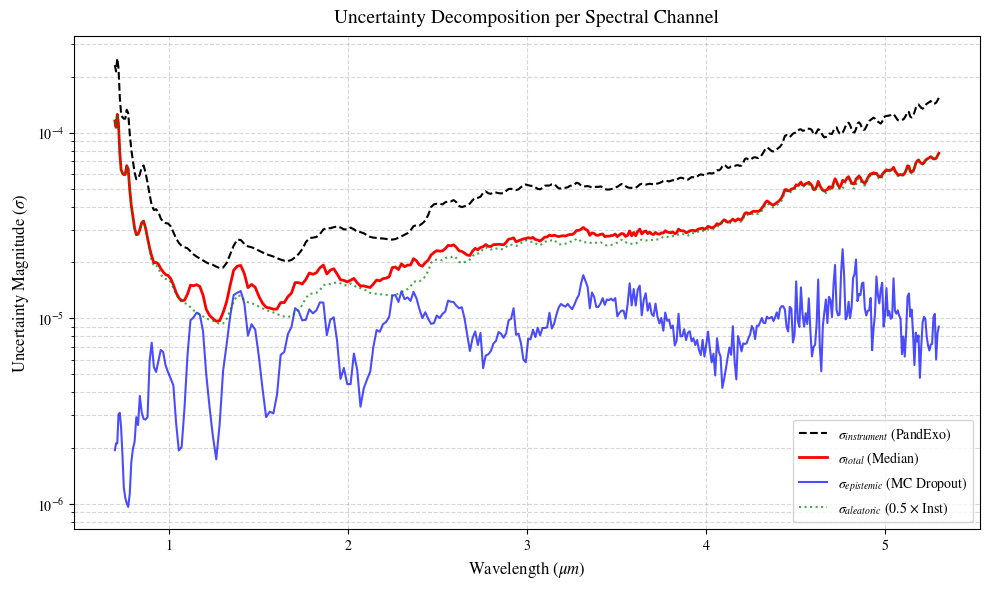

In [18]:
# Compute medians across the test set for visualization
sigma_ale_med = np.median(sigma_ale, axis=0)
sigma_epi_med = np.median(sigma_epi, axis=0)
sigma_tot_med = np.median(sigma_total, axis=0)

# --- Plot Uncertainty Breakdown ---

plt.figure(figsize=(10, 6))

# Plot components using the same wavelength ordering as the spectral arrays.
waves_plot = np.asarray(waves)[::-1]
plt.plot(waves_plot, noise_vector, label=r"$\sigma_{instrument}$ (PandExo)", color='black', linestyle='--', linewidth=1.5)
plt.plot(waves_plot, sigma_tot_med, label=r"$\sigma_{total}$ (Median)", color='red', linewidth=2)
plt.plot(waves_plot, sigma_epi_med, label=r"$\sigma_{epistemic}$ (MC Dropout)", color='blue', alpha=0.7)
plt.plot(waves_plot, sigma_ale_med, label=r"$\sigma_{aleatoric}$ (0.5 $\times$ Inst)", color='green', alpha=0.7, linestyle=':')

# Formatting
xlabel_text = r"Wavelength ($\mu m$)" if (waves.ndim==1 and not np.issubdtype(waves.dtype, np.integer)) else "Spectral Index"
plt.xlabel(xlabel_text, fontsize=12)
plt.ylabel(r"Uncertainty Magnitude ($\sigma$)", fontsize=12)
plt.title("Uncertainty Decomposition per Spectral Channel", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.yscale('log') # Log scale often helps visual separation
plt.tight_layout()

plt.show()


# Reduced $\chi^2_r$ Distribution for Airless Spectra

This section evaluates the reduced chi-squared ($\chi^2_r$) metrics specifically for the **airless** transmission spectra subset. Comparing the noisy observations and G-DAE reconstructions against clean airless references allows us to verify performance when no planetary spectral features are present, confirming that the total estimated uncertainty ($\sigma_{\text{tot}}$) properly calibrates the residual error ($\chi^2_r \approx 1$).


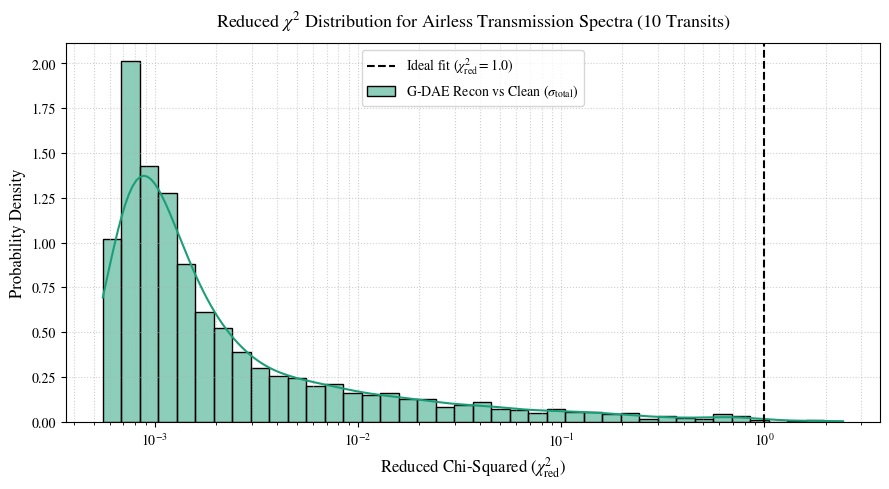

In [26]:
# --- Reduced Chi-Squared Analysis for Airless Spectra ---

# Filter airless spectra
if 'is_airless' not in globals() or is_airless is None:
    # Fallback to airless slice if mask is not directly available
    n_airless = int(10 * counts.get("Airless", 300))
    is_airless = np.zeros(X_clean_raw.shape[0], dtype=bool)
    is_airless[-n_airless:] = True

X_clean_airless = X_clean_raw.values[is_airless]
recon_airless = recon_mean[is_airless]
sigma_tot_airless = np.clip(sigma_total[is_airless], 1e-12, np.inf)

# Compute Reduced Chi-Squared (chi2_r with p=0 degrees of freedom consumed)
chi2r_airless_recon_tot = chi2_r(recon_airless, X_clean_airless, sigma_tot_airless, p=0)

# --- Plot Airless Reduced Chi-Squared Distribution ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    chi2r_airless_recon_tot,
    kde=True,
    stat="density",
    color="#1b9e77",
    label=r"G-DAE Recon vs Clean ($\sigma_{\mathrm{total}}$)",
    alpha=0.50,
    bins=40,
    log_scale=True,
    ax=ax,
)

# Reference line at ideal reduced chi2 = 1.0
ax.axvline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=r"Ideal fit ($\chi^2_{\mathrm{red}} = 1.0$)",
    zorder=10,
)

ax.set_xlabel(r"Reduced Chi-Squared ($\chi^2_{\mathrm{red}}$)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title(
    r"Reduced $\chi^2$ Distribution for Airless Transmission Spectra (10 Transits)",
    fontsize=13,
    pad=12,
)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle=":", alpha=0.6)

plt.tight_layout()

# Save plot
save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "airless_chi2r_distribution.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "airless_chi2r_distribution.pdf"), dpi=300, bbox_inches="tight")

plt.show()


## Spectra Reconstruction Visualization

C:\Users\User\AppData\Local\Temp\ipykernel_35708\229660977.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=1.0)


>>> Plot saved: plots/exp0-final_example-10Transit_v1.png


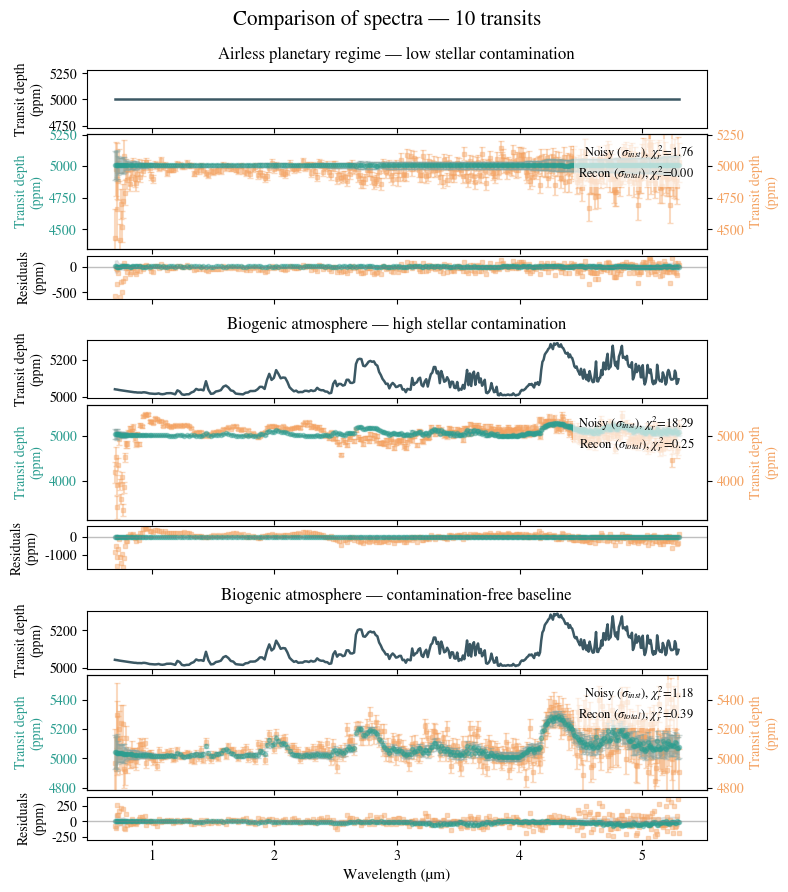

In [20]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

COLORS = {
    "original": "#264653",
    "reconstructed": "#2A9D8F",
    "noisy_points": "#F4A261",
    "fill_uq_resid": "#cccccc80",
    "recon_ecolor": "#85A39F",
}


idx_list = [46677, 42873, 1401]
titles = [
    "Airless planetary regime — low stellar contamination",
    "Biogenic atmosphere — high stellar contamination",
    "Biogenic atmosphere — contamination-free baseline",
]

# Map variables to the plot namespace
y_clean_all = X_clean
y_noisy_all = X_noisy
y_recon_all = recon_mean
sigma_total_all = sigma_total

idx_list = [idx for idx in idx_list if 0 <= idx < y_clean_all.shape[0]]
titles = titles[: len(idx_list)]
assert len(idx_list) > 0

waves_i = waves[::-1]

spacer = 1.0
height_ratios = []
for group_index in range(len(idx_list)):
    height_ratios.extend([2, 4, 1.5])
    if group_index < len(idx_list) - 1:
        height_ratios.append(spacer)

fig = plt.figure(figsize=(8, 10))
grid = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.1)

main_ax = None
stride = 4

formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)

for i, idx in enumerate(idx_list):
    base = stride * i

    if main_ax is None:
        ax_orig = fig.add_subplot(grid[base])
        main_ax = ax_orig
    else:
        ax_orig = fig.add_subplot(grid[base], sharex=main_ax)

    ax_mix = fig.add_subplot(grid[base + 1], sharex=main_ax)
    ax_resid = fig.add_subplot(grid[base + 2], sharex=main_ax)

    ax_orig.tick_params(labelbottom=False)
    ax_mix.tick_params(labelbottom=False)

    is_last_group = i == len(idx_list) - 1
    ax_resid.tick_params(labelbottom=is_last_group)
    if is_last_group:
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)

    y_clean = y_clean_all[idx]
    y_noisy = y_noisy_all[idx]
    y_recon = y_recon_all[idx]
    sigma_recon = sigma_total_all[idx]

    y_clean_ppm = y_clean * 1e6
    y_noisy_ppm = y_noisy * 1e6
    y_recon_ppm = y_recon * 1e6
    sigma_inst_ppm = sigma_inst * 1e6
    sigma_recon_ppm = sigma_recon * 1e6

    chi2r_noisy = chi2_r(y_clean[None, :], y_noisy[None, :], sigma_inst, p=0)[0]
    chi2r_recon = chi2_r(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]
    metrics_text = (
        rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_noisy:.2f}"
        "\n"
        rf"Recon ($\sigma_{{total}}$), $\chi^2_r$={chi2r_recon:.2f}"
    )

    ax_orig.plot(
        waves_i,
        y_clean_ppm,
        color=COLORS["original"],
        lw=1.8,
        alpha=0.9,
    )
    ax_orig.set_ylabel("Transit depth\n(ppm)")
    ax_orig.set_title(titles[i], fontsize=12, pad=8)
    ax_orig.yaxis.set_major_formatter(formatter)

    ax_mix_right = ax_mix.twinx()
    ax_mix.yaxis.set_major_formatter(formatter)
    ax_mix_right.yaxis.set_major_formatter(formatter)

    ax_mix_right.grid(False)
    ax_mix.set_zorder(3)
    ax_mix_right.set_zorder(2)
    ax_mix.patch.set_alpha(0.0)
    ax_mix_right.patch.set_alpha(0.0)

    ax_mix.set_ylabel("Transit depth\n(ppm)", color=COLORS["reconstructed"])
    ax_mix.tick_params(axis="y", labelcolor=COLORS["reconstructed"])
    ax_mix_right.set_ylabel("Transit depth\n(ppm)", color=COLORS["noisy_points"])
    ax_mix_right.tick_params(axis="y", labelcolor=COLORS["noisy_points"])

    ax_mix_right.errorbar(
        waves_i,
        y_noisy_ppm,
        yerr=sigma_inst_ppm,
        color=COLORS["noisy_points"],
        fmt="s",
        capsize=2,
        alpha=0.4,
        ms=3,
        zorder=8,
    )
    ax_mix.errorbar(
        waves_i,
        y_recon_ppm,
        yerr=sigma_recon_ppm,
        color=COLORS["reconstructed"],
        fmt="o",
        capsize=2,
        alpha=0.4,
        ms=3,
        ecolor=COLORS["recon_ecolor"],
        zorder=9,
    )

    all_vals = np.concatenate([y_noisy_ppm, y_recon_ppm])
    y_min = float(all_vals.min())
    y_max = float(all_vals.max())
    margin = 0.1 * (y_max - y_min) if y_max > y_min else 1.0

    ax_mix.set_ylim(y_min - margin, y_max + margin)
    ax_mix_right.set_ylim(y_min - margin, y_max + margin)
    ax_mix.text(
        0.98,
        0.92,
        metrics_text,
        transform=ax_mix.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=3.0),
        zorder=20,
    )

    resid_noisy = (y_noisy - y_clean) * 1e6
    resid_recon = (y_recon - y_clean) * 1e6

    ax_resid.fill_between(
        waves_i,
        -sigma_recon_ppm,
        sigma_recon_ppm,
        color=COLORS["fill_uq_resid"],
        zorder=0,
    )
    ax_resid.plot(
        waves_i,
        resid_noisy,
        "s",
        color=COLORS["noisy_points"],
        alpha=0.4,
        ms=3,
        zorder=1,
    )
    ax_resid.plot(
        waves_i,
        resid_recon,
        "o",
        color=COLORS["reconstructed"],
        alpha=0.4,
        ms=3,
        zorder=2,
    )

    ax_resid.axhline(0, color="gray", lw=1, alpha=0.5)
    ax_resid.set_ylabel("Residuals\n(ppm)")
    ax_resid.yaxis.set_major_formatter(formatter)

fig.suptitle(f"Comparison of spectra — {N_TRANSITS} transits", fontsize=15, y=0.94)
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=1.0)

os.makedirs("plots", exist_ok=True)
output_path = f"plots/exp0-final_example-10Transit_v1.png"
#plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f">>> Plot saved: {output_path}")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_35708\979647921.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93], h_pad=0.5)


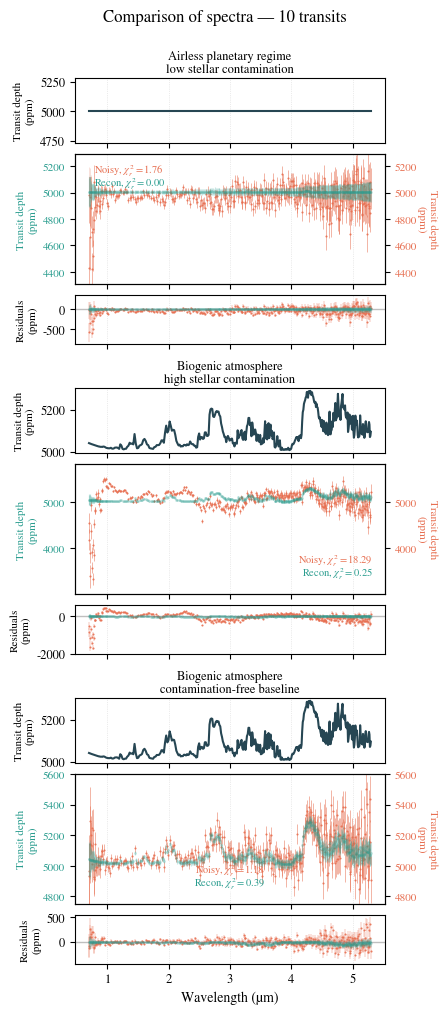

In [21]:
import os
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter


COLORS = {
    "original": "#264653",
    "reconstructed": "#2A9D8F",
    "noisy_points": "#E76F51",
    "fill_uq_resid": "#cccccc80",
}

IDX_LIST = [46677, 42873, 1401]

TITLES = [
    "Airless planetary regime\nlow stellar contamination",
    "Biogenic atmosphere\nhigh stellar contamination",
    "Biogenic atmosphere\ncontamination-free baseline",
]


def create_plot_final_text(
    recon_mean: np.ndarray,
    sigma_total: np.ndarray,
    x_clean_raw: np.ndarray,
    x_noisy_raw: np.ndarray,
    sigma_inst: np.ndarray,
    waves: np.ndarray,
    n_transits: int,
    save_dir: str = "plots",
    save: bool = False,
    filename_stem: str = "exp0-final_example-10Transit_v2",
    idx_list: Sequence[int] = IDX_LIST,
    titles: Sequence[str] = TITLES,
) -> None:
    y_recon_all = np.asarray(recon_mean)
    sigma_total_all = np.asarray(sigma_total)
    y_clean_all = np.asarray(x_clean_raw)
    y_noisy_all = np.asarray(x_noisy_raw)
    sigma_inst_arr = np.asarray(sigma_inst)
    waves_arr = np.asarray(waves)[::-1]

    if not (
        y_clean_all.shape
        == y_noisy_all.shape
        == y_recon_all.shape
        == sigma_total_all.shape
    ):
        raise ValueError("Input arrays must have identical shape (n_samples, n_waves).")

    n_waves = y_clean_all.shape[1]
    if sigma_inst_arr.shape != (n_waves,):
        raise ValueError("sigma_inst must have shape (n_waves,).")

    if waves_arr.shape != (n_waves,):
        raise ValueError("waves must have shape (n_waves,).")

    valid_idx = [idx for idx in idx_list if 0 <= idx < y_clean_all.shape[0]]
    if not valid_idx:
        raise ValueError("No valid indices to plot (idx_list out of range).")

    titles_used = list(titles)[: len(valid_idx)]
    if len(titles_used) < len(valid_idx):
        titles_used.extend([""] * (len(valid_idx) - len(titles_used)))

    plt.rcParams.update({"font.size": 9, "font.family": "serif"})
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)

    spacer = 0.7
    height_ratios: list[float] = []
    for group_index in range(len(valid_idx)):
        height_ratios.extend([2.0, 4.0, 1.5])
        if group_index < len(valid_idx) - 1:
            height_ratios.append(spacer)

    fig = plt.figure(figsize=(4, 11.5))
    grid = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    main_ax = None
    stride = 4

    for i, idx in enumerate(valid_idx):
        base = stride * i

        if main_ax is None:
            ax_orig = fig.add_subplot(grid[base])
            main_ax = ax_orig
        else:
            ax_orig = fig.add_subplot(grid[base], sharex=main_ax)

        ax_mix = fig.add_subplot(grid[base + 1], sharex=main_ax)
        ax_resid = fig.add_subplot(grid[base + 2], sharex=main_ax)

        for ax in (ax_orig, ax_mix, ax_resid):
            ax.grid(axis="x", color="gray", linestyle=":", linewidth=0.5, alpha=0.3)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        is_last_group = i == len(valid_idx) - 1
        ax_resid.tick_params(labelbottom=is_last_group)
        if is_last_group:
            ax_resid.set_xlabel("Wavelength (µm)", fontsize=10)

        y_clean = y_clean_all[idx]
        y_noisy = y_noisy_all[idx]
        y_recon = y_recon_all[idx]
        sigma_recon = sigma_total_all[idx]

        y_clean_ppm = y_clean * 1e6
        y_noisy_ppm = y_noisy * 1e6
        y_recon_ppm = y_recon * 1e6
        sigma_inst_ppm = sigma_inst_arr * 1e6
        sigma_recon_ppm = sigma_recon * 1e6

        chi2r_noisy = chi2_r(
            y_clean[None, :],
            y_noisy[None, :],
            sigma_inst_arr,
            p=0,
        )[0]
        chi2r_recon = chi2_r(
            y_clean[None, :],
            y_recon[None, :],
            sigma_recon,
            p=0,
        )[0]

        ax_orig.plot(
            waves_arr,
            y_clean_ppm,
            color=COLORS["original"],
            lw=1.5,
            alpha=1.0,
        )
        ax_orig.set_ylabel("Transit depth\n(ppm)", fontsize=8)
        ax_orig.set_title(titles_used[i], fontsize=9, pad=4)
        ax_orig.yaxis.set_major_formatter(formatter)

        ax_mix_right = ax_mix.twinx()
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_right.yaxis.set_major_formatter(formatter)

        ax_mix_right.grid(False)
        ax_mix.set_zorder(3)
        ax_mix_right.set_zorder(2)
        ax_mix.patch.set_alpha(0.0)
        ax_mix_right.patch.set_alpha(0.0)

        ax_mix.set_ylabel(
            "Transit depth\n(ppm)",
            color=COLORS["reconstructed"],
            fontsize=8,
        )
        ax_mix.tick_params(axis="y", labelcolor=COLORS["reconstructed"], labelsize=8)

        ax_mix_right.set_ylabel(
            "Transit depth\n(ppm)",
            color=COLORS["noisy_points"],
            fontsize=8,
            rotation=270,
            labelpad=15,
        )
        ax_mix_right.tick_params(axis="y", labelcolor=COLORS["noisy_points"], labelsize=8)

        ax_mix_right.errorbar(
            waves_arr,
            y_noisy_ppm,
            yerr=sigma_inst_ppm,
            color=COLORS["noisy_points"],
            fmt="o",
            alpha=0.9,
            ms=1.5,
            markeredgewidth=0.0,
            elinewidth=0.4,
            capsize=0.0,
            zorder=1,
        )

        ax_mix.errorbar(
            waves_arr,
            y_recon_ppm,
            yerr=sigma_recon_ppm,
            color=COLORS["reconstructed"],
            fmt="o",
            alpha=0.25,
            ms=2.0,
            markeredgewidth=0.0,
            elinewidth=0.8,
            capsize=0.0,
            zorder=10,
        )

        all_vals = np.concatenate([y_noisy_ppm, y_recon_ppm])
        y_min = float(all_vals.min())
        y_max = float(all_vals.max())
        margin = 0.15 * (y_max - y_min) if y_max > y_min else 1.0

        ax_mix.set_ylim(y_min - margin, y_max + margin)
        ax_mix_right.set_ylim(y_min - margin, y_max + margin)

        if i == 0:
            box_x, box_y = 0.04, 0.94
            text_x = 0.06
            noisy_y, recon_y = 0.94, 0.84
            ha, va = "left", "top"
        elif i == 1:
            box_x, box_y = 0.98, 0.12
            text_x = 0.96
            noisy_y, recon_y = 0.20, 0.10
            ha, va = "right", "bottom"
        else:
            box_x, box_y = 0.50, 0.12
            text_x = 0.50
            noisy_y, recon_y = 0.20, 0.10
            ha, va = "center", "bottom"

        # Soft background so the text doesn't get lost
        ax_mix.text(
            box_x,
            box_y,
            " ",
            transform=ax_mix.transAxes,
            ha=ha,
            va=va,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.60, pad=2.8),
            zorder=19,
        )

        # Chi2 labels matching the series color
        ax_mix.text(
            text_x,
            noisy_y,
            rf"Noisy, $\chi^2_r={chi2r_noisy:.2f}$",
            transform=ax_mix.transAxes,
            ha=ha,
            va=va,
            fontsize=7.5,
            color=COLORS["noisy_points"],
            zorder=20,
        )
        ax_mix.text(
            text_x,
            recon_y,
            rf"Recon, $\chi^2_r={chi2r_recon:.2f}$",
            transform=ax_mix.transAxes,
            ha=ha,
            va=va,
            fontsize=7.5,
            color=COLORS["reconstructed"],
            zorder=20,
        )

        resid_noisy = (y_noisy - y_clean) * 1e6
        resid_recon = (y_recon - y_clean) * 1e6

        ax_resid.fill_between(
            waves_arr,
            -sigma_recon_ppm,
            sigma_recon_ppm,
            color=COLORS["fill_uq_resid"],
            zorder=0,
            alpha=0.25,
        )

        ax_resid.errorbar(
            waves_arr,
            resid_noisy,
            yerr=sigma_inst_ppm,
            fmt="o",
            color=COLORS["noisy_points"],
            alpha=0.9,
            ms=1.5,
            markeredgewidth=0.0,
            elinewidth=0.3,
            capsize=0.0,
            zorder=1,
        )

        ax_resid.errorbar(
            waves_arr,
            resid_recon,
            yerr=sigma_recon_ppm,
            fmt="o",
            color=COLORS["reconstructed"],
            alpha=0.25,
            ms=2.0,
            markeredgewidth=0.0,
            elinewidth=0.6,
            capsize=0.0,
            zorder=2,
        )

        ax_resid.axhline(0.0, color="gray", lw=1.0, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)", fontsize=8)
        ax_resid.yaxis.set_major_formatter(formatter)

    fig.suptitle(f"Comparison of spectra — {n_transits} transits", fontsize=12, y=0.94)
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93], h_pad=0.5)

    if save:
        os.makedirs(save_dir, exist_ok=True)
        output_path = os.path.join(save_dir, f"{filename_stem}.png")
        plt.savefig(output_path, dpi=500, bbox_inches="tight")
        output_path = os.path.join(save_dir, f"{filename_stem}.pdf")
        plt.savefig(output_path, dpi=500, bbox_inches="tight")

    plt.show()


create_plot_final_text(
    recon_mean=recon_mean,
    sigma_total=sigma_total,
    x_clean_raw=X_clean_raw.values,
    x_noisy_raw=X_noisy_raw.values,
    sigma_inst=sigma_inst,
    waves=waves,
    n_transits=10,
    save_dir="plots",
    save=True,
    filename_stem="exp0-final_example-10Transit_v2",
)

# Analysis of stellar contamination and SNR

In [22]:
clean_dataset_specs = [
    ("airless_data_clean", "spec_data/airless_data.csv", False),
    ("CO2_data_clean", "spec_data/CO2_data.csv", False),
    ("CH4_data_clean", "spec_data/CH4_data.csv", True),
    ("O3_data_clean", "spec_data/O3_data.csv", True),
    ("H2O_data_clean", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data_clean", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data_clean", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data_clean", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data_clean", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in clean_dataset_specs:
    try:
        df = pd.read_csv(path)
        if needs_filter:
            df = filter_rows(df, N_POINTS)
        globals()[name] = mult_df(df, N_POINTS, 0)
    except Exception as e:
        print(f"Error processing {name}: {e}")


In [23]:
import pickle

"""
Sensitivity and uncertainty quantification (UQ) analysis over multiple
transit counts and stellar heterogeneity configurations.
"""

# =============================================================================
# Configuration
# =============================================================================
N_TRANSITS_LIST: list[int] = [1, 2, 3, 5, 7, 10, 15, 20]

F_SPOT_VALUES: list[float] = [0.0, 0.01, 0.08, 0.26]
F_FAC_VALUES: list[float] = [0.0, 0.08, 0.54, 0.70]
FACTOR: float = 10.0 / 8.0

T_PASSES_DROPOUT: int = 100
EPS_SIGMA: float = 1e-12

PANDEXO_SPEC_PATH: str = "pandexo_spec.txt"
OUTPUT_FILENAME: str = "results_by_transits.pkl"


# =============================================================
# Helpers
# =============================================================================
def filter_by_heterogeneity(
    df: pd.DataFrame,
    f_spot: float,
    f_fac: float,
) -> pd.DataFrame:
    """Return a subset matching the stellar heterogeneity (f_spot, f_fac)."""
    return df[(df["f_spot"] == f_spot) & (df["f_fac"] == f_fac)]


def is_valid_pair(f_spot: float, f_fac: float) -> bool:
    """
    Keep only (0, 0) or pairs where both values are non-zero.

    This reproduces the original condition:
        if (f_spot == 0) ^ (f_fac == 0): continue
    """
    return not ((f_spot == 0.0) ^ (f_fac == 0.0))


def build_master_clean_dataset(
    n_ch4_o3_h2o: int,
    n_airless: int,
) -> pd.DataFrame:
    """Build the master clean dataset once (noise std = 0)."""
    clean_df = pd.concat(
        [
            generate_df_with_noise_std(CH4_O3_H2O_data_clean, n_ch4_o3_h2o, 0),
            generate_df_with_noise_std(airless_data_clean, n_airless, 0),
        ],
        ignore_index=True,
    )
    return attach_spectrum_blocks(clean_df, N_POINTS)


def build_noisy_dataset(
    instrumental_noise: np.ndarray,
    n_ch4_o3_h2o: int,
    n_airless: int,
) -> pd.DataFrame:
    """Build the noisy dataset for a given instrumental noise vector."""
    noisy_df = pd.concat(
        [
            generate_df_with_noise_std(CH4_O3_H2O_data, n_ch4_o3_h2o, instrumental_noise),
            generate_df_with_noise_std(airless_data, n_airless, instrumental_noise),
        ],
        ignore_index=True,
    )
    return attach_spectrum_blocks(noisy_df, N_POINTS)


def load_instrumental_noise(n_transits: int) -> np.ndarray:
    """Load PandExo noise and flip it once into the model / CSV spectral order."""
    noise_pandexo = get_pandexo_noise_from_file(PANDEXO_SPEC_PATH, n_transits=n_transits, plot=False)
    noise_model = np.asarray(noise_pandexo[::-1], dtype=np.float32)

    if noise_model.ndim != 1:
        raise ValueError("Expected a 1D instrumental noise vector per wavelength.")

    return noise_model


# =============================================================================
# Main
# =============================================================================
print("Building master CLEAN dataset (one-time)...")

n_ch4_o3_h2o_master: int = int(2 * FACTOR * FACTOR * FACTOR)
n_airless_master: int = int(100 * 3)

ref_flat = float(REF_FLAT) if REF_FLAT is not None else infer_ref_flat_from_airless(
    airless_data, N_POINTS
)
print(f"Using ref_flat = {ref_flat:.12e}")

df_clean_master: pd.DataFrame = build_master_clean_dataset(
    n_ch4_o3_h2o=n_ch4_o3_h2o_master,
    n_airless=n_airless_master,
)

print("Master CLEAN dataset ready.")

all_results: dict[tuple[float, float], dict[str, list[Any]]] = {}

print("\nStarting sensitivity & UQ analysis...")

for f_spot_value in F_SPOT_VALUES:
    for f_fac_value in F_FAC_VALUES:
        if not is_valid_pair(f_spot_value, f_fac_value):
            continue

        scores: dict[str, list[Any]] = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        df_clean_filtered: pd.DataFrame = df_clean_master

        desc = f"Processing f_spot={f_spot_value}, f_fac={f_fac_value}"
        for n_transits in tqdm(N_TRANSITS_LIST, desc=desc, leave=True):
            instrumental_noise = load_instrumental_noise(n_transits=n_transits)

            df_noisy = build_noisy_dataset(
                instrumental_noise=instrumental_noise,
                n_ch4_o3_h2o=n_ch4_o3_h2o_master,
                n_airless=n_airless_master,
            )

            df_noisy_filtered = filter_by_heterogeneity(
                df=df_noisy,
                f_spot=f_spot_value,
                f_fac=f_fac_value,
            )

            print(f"\n>> n_transits={n_transits}, f_spot={f_spot_value}, f_fac={f_fac_value}")
            print(
                "   - Instrumental noise mean (scalar over λ): "
                f"{instrumental_noise.mean():.6e}"
            )
            print(f"   - # noisy samples: {df_noisy_filtered.shape[0]}")
            print(f"   - # clean samples: {df_clean_filtered.shape[0]}")

            if df_noisy_filtered.empty:
                scores["n_transits"].append(n_transits)
                scores["chi2r_noisy_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_total"].append(np.nan)

                nan_vec = np.full((N_POINTS,), np.nan, dtype=np.float32)
                scores["sigma_inst_mean_lambda"].append(nan_vec.copy())
                scores["sigma_ale_mean_lambda"].append(nan_vec.copy())
                scores["sigma_epi_mean_lambda"].append(nan_vec.copy())
                scores["sigma_total_mean_lambda"].append(nan_vec.copy())

                del nan_vec, instrumental_noise, df_noisy, df_noisy_filtered
                gc.collect()
                continue

            x_noisy_raw = df_noisy_filtered.iloc[:, -N_POINTS:].copy()
            x_clean_raw = df_clean_filtered.iloc[:, -N_POINTS:].copy()

            if x_noisy_raw.shape[0] != x_clean_raw.shape[0]:
                raise RuntimeError(
                    "Row mismatch clean/noisy: "
                    f"{x_clean_raw.shape[0]} vs {x_noisy_raw.shape[0]}"
                )

            del df_noisy, df_noisy_filtered
            gc.collect()

            sigma_ale = calc_aleatoric_half_instrumental(
                sigma_inst=instrumental_noise,
                shape=x_noisy_raw.shape,
            )

            recon_mean, sigma_epi = mc_dropout_sigma_ref_flat(
                autoencoder=autoencoder,
                x_noisy_raw=x_noisy_raw,
                ref_flat=ref_flat,
                t_passes=T_PASSES_DROPOUT,
            )

            sigma_total = combine_uncertainties(
                sigma_ale=sigma_ale,
                sigma_epi=sigma_epi,
                floor=EPS_SIGMA,
            )

            sigma_inst_mean_lambda = instrumental_noise.astype(np.float32)
            sigma_ale_mean_lambda = np.nanmean(sigma_ale, axis=0).astype(np.float32)
            sigma_epi_mean_lambda = np.nanmean(sigma_epi, axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total, axis=0).astype(np.float32)

            chi2r_noisy_clean_inst = np.asarray(
                chi2_r(
                    x_clean_raw.values,
                    x_noisy_raw.values,
                    instrumental_noise,
                    p=0,
                ),
                dtype=np.float32,
            )
            chi2r_recon_clean_inst = np.asarray(
                chi2_r(
                    x_clean_raw.values,
                    recon_mean,
                    instrumental_noise,
                    p=0,
                ),
                dtype=np.float32,
            )
            chi2r_recon_clean_total = np.asarray(
                chi2_r(
                    x_clean_raw.values,
                    recon_mean,
                    sigma_total,
                    p=0,
                ),
                dtype=np.float32,
            )

            print(f"   - chi2_r (noisy vs clean | inst): {float(np.mean(chi2r_noisy_clean_inst)):.4f}")
            print(f"   - chi2_r (recon vs clean | inst): {float(np.mean(chi2r_recon_clean_inst)):.4f}")
            print(
                "   - chi2_r (recon vs clean | total): "
                f"{float(np.mean(chi2r_recon_clean_total)):.4f}"
            )

            scores["n_transits"].append(n_transits)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_noisy_clean_inst)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_recon_clean_inst)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_recon_clean_total)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)

            del (
                instrumental_noise,
                x_noisy_raw,
                x_clean_raw,
                sigma_ale,
                recon_mean,
                sigma_epi,
                sigma_total,
                chi2r_noisy_clean_inst,
                chi2r_recon_clean_inst,
                chi2r_recon_clean_total,
            )
            gc.collect()

        all_results[(f_spot_value, f_fac_value)] = scores

print("\nDone.")

with open(OUTPUT_FILENAME, "wb") as file:
    pickle.dump(all_results, file)

print(f"Results saved to: '{OUTPUT_FILENAME}'")


Building master CLEAN dataset (one-time)...
Using ref_flat = 5.006817635149e-03
Master CLEAN dataset ready.

Starting sensitivity & UQ analysis...


Processing f_spot=0.0, f_fac=0.0:   0%|          | 0/8 [00:00<?, ?it/s]

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit

>> n_transits=1, f_spot=0.0, f_fac=0.0
   - Instrumental noise mean (scalar over λ): 2.186545e-04
   - # noisy samples: 4908
   - # clean samples: 4908
Running 100 MC Dropout passes in 3 batch(es) (batch_size=2048)...
  batch 1/3 done
  batch 3/3 done
   - chi2_r (noisy vs clean | inst): 1.0004
   - chi2_r (recon vs clean | inst): 0.0589
   - chi2_r (recon vs clean | total): 0.2103


...

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit

>> n_transits=20, f_spot=0.26, f_fac=0.7
   - Instrumental noise mean (scalar over λ): 4.889263e-05
   - # noisy samples: 4908
   - # clean samples: 4908
Running 100 MC Dropout passes in 3 batch(es) (batch_size=2048)...
  batch 1/3 done
  batch 3/3 done
   - chi2_r (noisy vs clean | inst): 34.3526
   - chi2_r (recon vs clean | inst): 0.1025
   - chi2_r (recon vs clean | total): 0.1868


Processing f_spot=0.26, f_fac=0.7: 100%|██████████| 8/8 [04:04<00:00, 30.53s/it]


Done.
Results saved to: 'results_by_transits.pkl'


# Plot Transit-Count Diagnostics


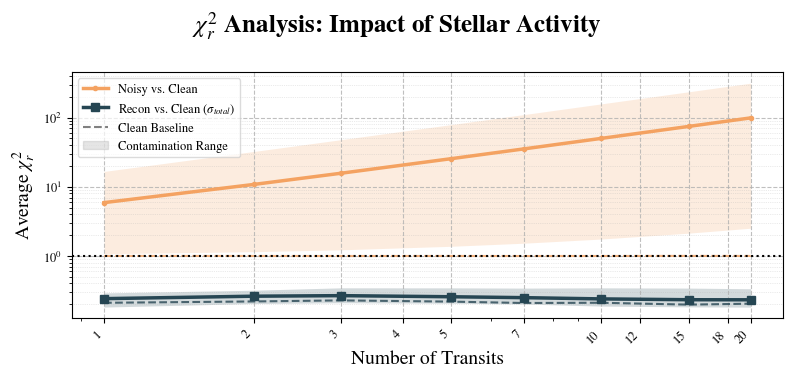

In [25]:
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# --- Files ---
filename = "results_by_transits.pkl"
output_dir = "plots"
output_png = "exp0-final_chi2r_analysis_02-comp.png"

# --- Plot configuration ---
base_key = (0.0, 0.0)  # clean baseline (no spots, no faculae)
metrics = ("chi2r_noisy_clean_inst", "chi2r_recon_clean_total")

labels = {
    "chi2r_noisy_clean_inst": r"Noisy vs. Clean",
    "chi2r_recon_clean_total": r"Recon vs. Clean ($\sigma_{total}$)",
}
colors = {
    "chi2r_noisy_clean_inst": "#F4A261",
    "chi2r_recon_clean_total": "#264653",
}
markers = {"chi2r_noisy_clean_inst": ".", "chi2r_recon_clean_total": "s"}

# --- Load results ---
with open(filename, "rb") as f:
    all_results = pickle.load(f)

# X-axis (number of transits) comes from the baseline case
base = all_results[base_key]
transits = list(map(int, base["n_transits"]))
x = np.asarray(transits, dtype=float)

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(
    r"$\chi^2_r$ Analysis: Impact of Stellar Activity",
    fontsize=18,
    y=0.96,
    fontweight="bold",
)

# --- Plot each metric: contamination band + contaminated mean + clean baseline ---
for metric in metrics:
    mins, maxs, means = [], [], []

    # Aggregate contaminated scenarios (exclude the baseline)
    for nt in transits:
        vals = []
        for key, data in all_results.items():
            if key == base_key or nt not in data["n_transits"]:
                continue

            idx = data["n_transits"].index(nt)
            v = data[metric][idx]
            if np.isfinite(v):
                vals.append(v)

        mins.append(np.min(vals) if vals else np.nan)
        maxs.append(np.max(vals) if vals else np.nan)
        means.append(np.mean(vals) if vals else np.nan)

    mins = np.asarray(mins, dtype=float)
    maxs = np.asarray(maxs, dtype=float)
    means = np.asarray(means, dtype=float)

    # Clean baseline curve for the same metric
    baseline = np.asarray(
        [base[metric][base["n_transits"].index(nt)] for nt in transits],
        dtype=float,
    )

    # Range (min-max), contaminated mean, and baseline (dashed)
    ax.fill_between(x, mins, maxs, color=colors[metric], alpha=0.2, linewidth=0)
    ax.plot(
        x,
        means,
        color=colors[metric],
        marker=markers[metric],
        lw=2.5,
        label=labels[metric],
    )
    ax.plot(x, baseline, color=colors[metric], lw=1.5, ls="--", alpha=0.8)

# --- Axes styling ---
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of Transits", fontsize=14)
ax.set_ylabel(r"Average $\chi^2_r$", fontsize=14)

# Use data ticks + a few extra ticks to reduce visual gaps
ax.set_xticks(sorted(set(transits) | {4, 12, 18}))
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(True, which="major", ls="--", lw=0.8, alpha=0.8)
ax.grid(True, which="minor", axis="y", ls=":", lw=0.5, alpha=0.5)

# Reference line: ideal chi2_r ~ 1
ax.axhline(1.0, color="black", ls=":", lw=1.5)

# --- Legend: metric labels + style explanation ---
h, lab = ax.get_legend_handles_labels()
h += [
    Line2D([0], [0], color="gray", ls="--", lw=1.5),
    Rectangle((0, 0), 1, 1, color="gray", alpha=0.2),
]
lab += ["Clean Baseline", "Contamination Range"]
ax.legend(h, lab, fontsize=9, loc="upper left", framealpha=0.7)

os.makedirs(output_dir, exist_ok=True)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(os.path.join(output_dir, output_png), dpi=500)
plt.show()
